In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.interpolate import interp1d
from scipy.signal import spectrogram
from scipy.stats import kurtosis

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import seaborn as sns

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

In [41]:
from sklearn.metrics import accuracy_score

In [6]:
# LOAD TRAIN, VALIDATION, AND TEST DATASETS
train_file = "datasets/train.csv"
val_file = "datasets/validation.csv"
test_file = "datasets/testing.csv"

train_df = pd.read_csv(train_file)
val_df = pd.read_csv(val_file)
test_df = pd.read_csv(test_file)

train_df.head()
# csvfile["timestamp"] = pd.to_numeric(csvfile["timestamp"], errors="coerce")


,timestamp,print_id,print_state,state_flag,x_rms,y_rms,z_rms,x_std,y_std,z_std,...,z_crest,x_magn,y_magn,z_magn,c_magn,c_rms,c_std,c_mean,c_kurt,c_crest
0,2025-10-23 16:36:55.384982,octopus_11,c,0,1456.520168,1436.391961,-241.307137,5.927882,5.132837,1772.704373,...,1.862842,NaN,NaN,NaN,NaN,2059.830576,1772.721716,1772.712923,NaN,NaN
1,2025-10-23 16:36:55.483878,octopus_11,c,0,1426.911354,1402.141709,-264.716150,5.798158,5.239344,1737.768439,...,1.979065,NaN,NaN,NaN,NaN,2017.957389,1737.786010,1737.776405,NaN,NaN
2,2025-10-23 16:36:55.583806,octopus_11,c,0,1387.261267,1365.400911,-245.304249,5.677633,5.389093,1717.778628,...,1.982754,NaN,NaN,NaN,NaN,1961.883698,1717.796464,1717.786497,NaN,NaN
3,2025-10-23 16:36:55.592148,octopus_11,c,0,1516.150661,1494.261081,-256.703421,7.931846,6.053853,1814.431844,...,1.986539,NaN,NaN,NaN,NaN,2144.160827,1814.459280,1814.441222,NaN,NaN
4,2025-10-23 16:36:55.680922,octopus_11,c,0,1493.129511,1471.436556,-253.594556,8.085420,6.147192,1856.905122,...,1.974991,NaN,NaN,NaN,NaN,2111.604006,1856.932900,1856.913482,NaN,NaN


# Feature Visualization

In [ ]:
train_df['c_crest'].hist(bins=50)
plt.title("Combined (all axes) crest factor")
plt.show()

train_df['c_rms'].hist(bins=50)
plt.title("Combined (all axes) root mean square")
plt.show()

train_df['z_rms'].hist(bins=50)
plt.title("z-axis RMS")
plt.show()


In [ ]:
features_to_viz = ["x_rms", "z_rms", "c_rms", "c_crest", "c_magn", "z_kurt", "y_kurt", "z_magn"]

unclogged_df = train_df[train_df["print_state"] == "u"]
clogged_df = train_df[train_df["print_state"] == "c"]

# Plot histograms
for feat in features_to_viz:
    plt.figure(figsize=(8, 4))
    plt.hist(unclogged_df[feat], bins=50, alpha=0.6, label="Unclogged", color='blue')
    plt.hist(clogged_df[feat], bins=50, alpha=0.6, label="Clogged", color='red')
    plt.title(f"Histogram of {feat} by Print State")
    plt.xlabel(feat)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

As shown above, some features with noticeable differences in feature histograms between clogged and unclogged prints include z_magn, y_kurt, z_curt, z_rms, and c_rms.

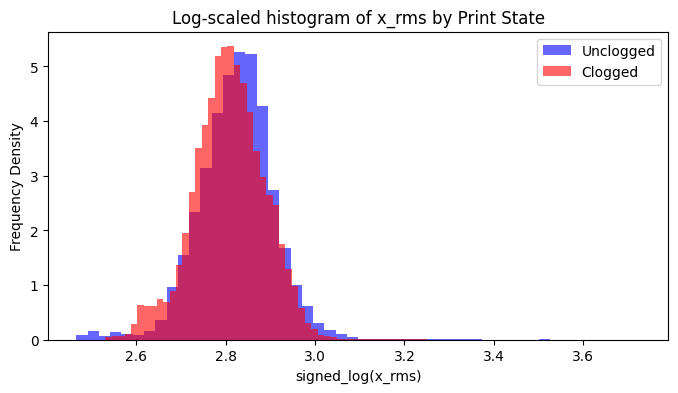

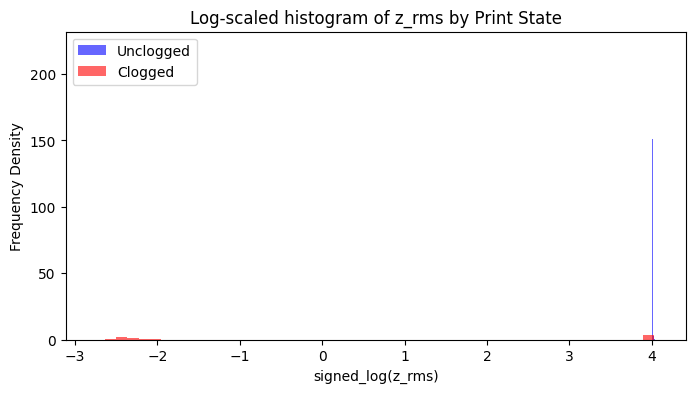

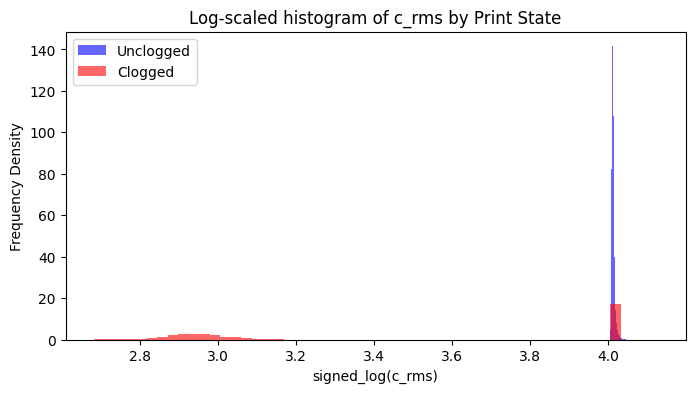

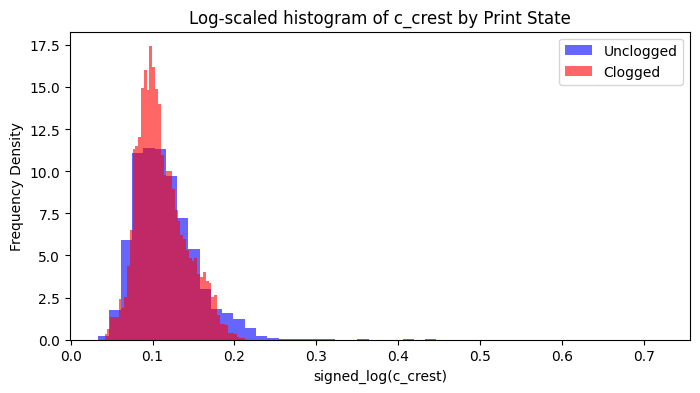

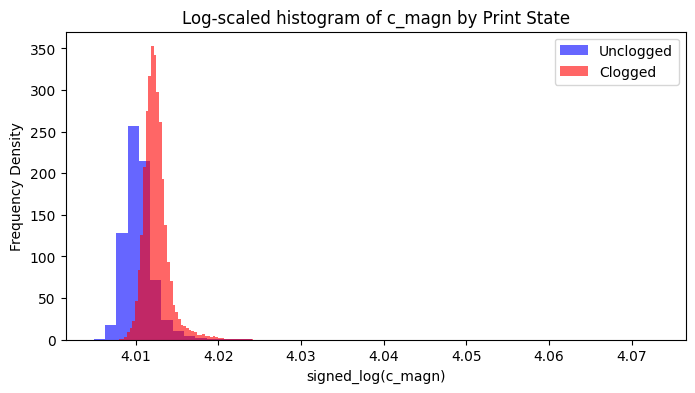

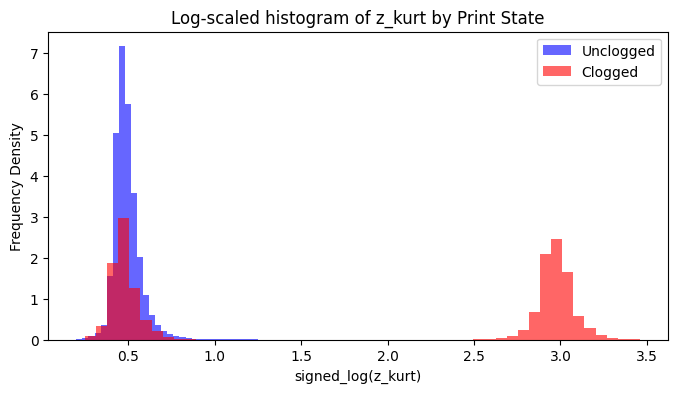

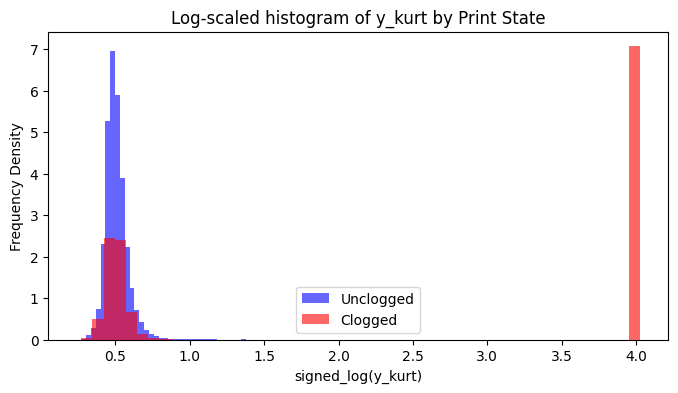

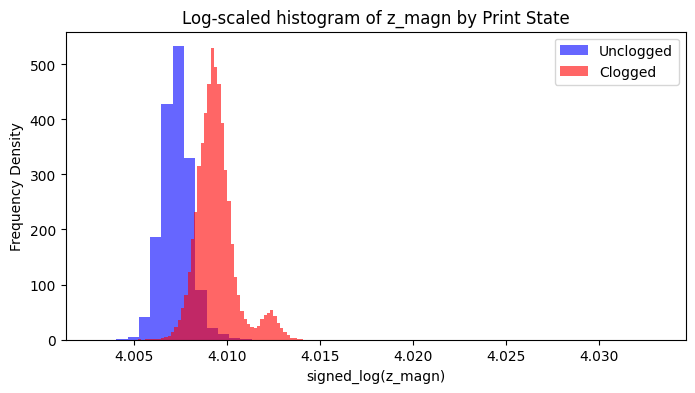

In [28]:
eps = 1e-6
# we have negative values for some features, so need signed log to handle viz
def signed_log(x, eps=1e-6):
    return np.sign(x) * np.log10(np.abs(x) + eps)

for feat in features_to_viz:
    plt.figure(figsize=(8, 4))
    
    # log-transform
    #unclogged_vals = np.log10(unclogged_df[feat] + eps)
    #clogged_vals   = np.log10(clogged_df[feat] + eps)
    unclogged_vals = signed_log(unclogged_df[feat] + eps)
    clogged_vals = signed_log(clogged_df[feat] + eps)
    
    # set density = true to scale histograms since clogged vs unclogged classes are unbalanced
    plt.hist(unclogged_vals, bins=50, alpha=0.6, label="Unclogged", color='blue', density=True)
    plt.hist(clogged_vals, bins=50, alpha=0.6, label="Clogged", color='red', density=True)
    
    plt.title(f"Log-scaled histogram of {feat} by Print State")
    plt.xlabel(f"signed_log({feat})")
    plt.ylabel("Frequency Density")
    plt.legend()
    plt.show()

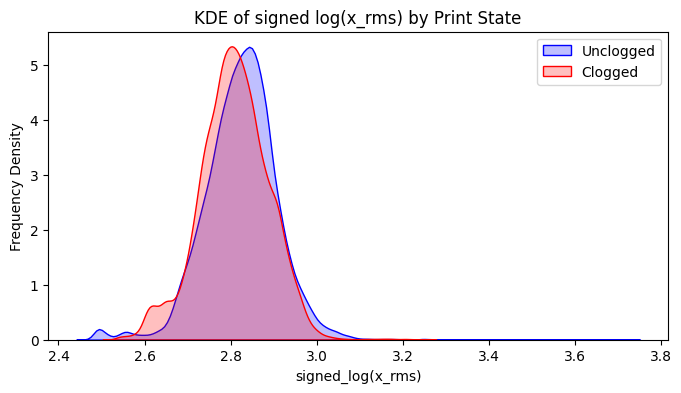

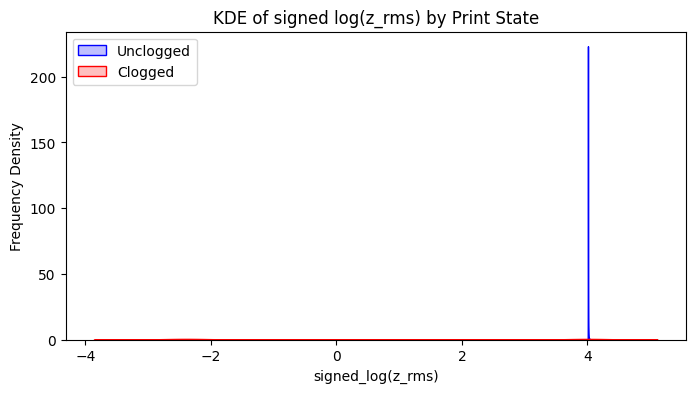

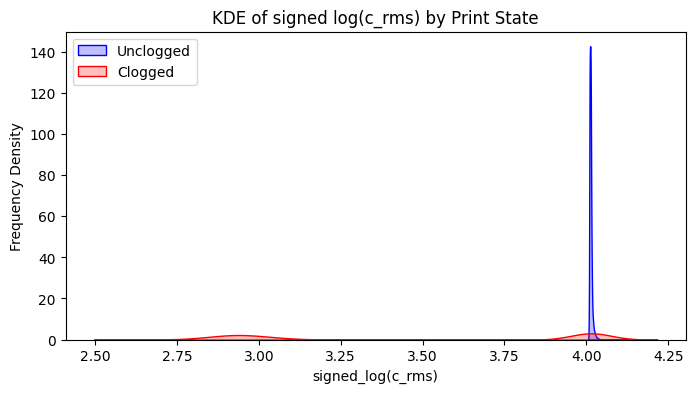

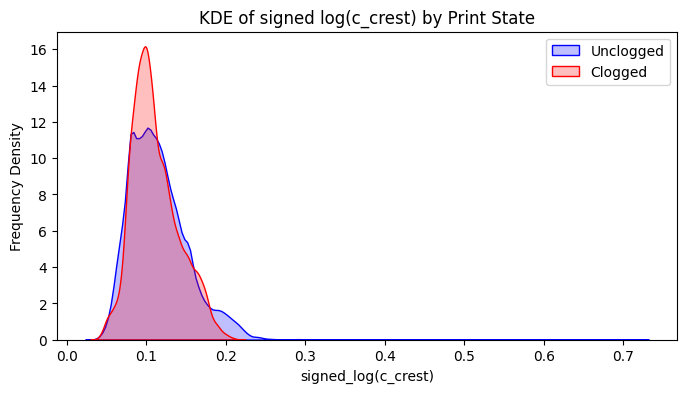

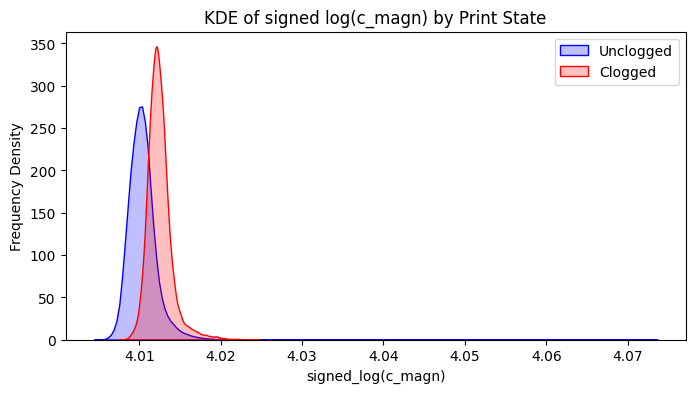

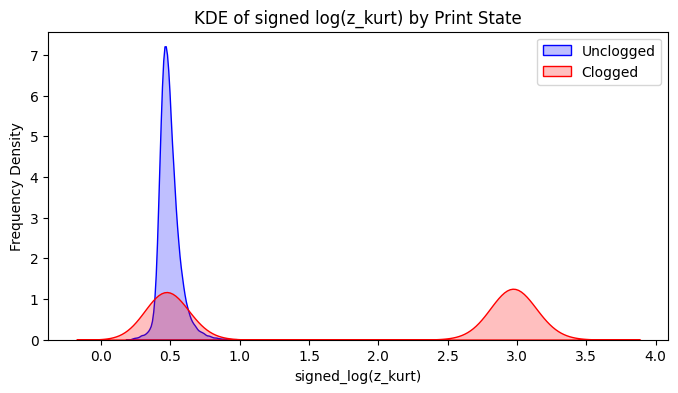

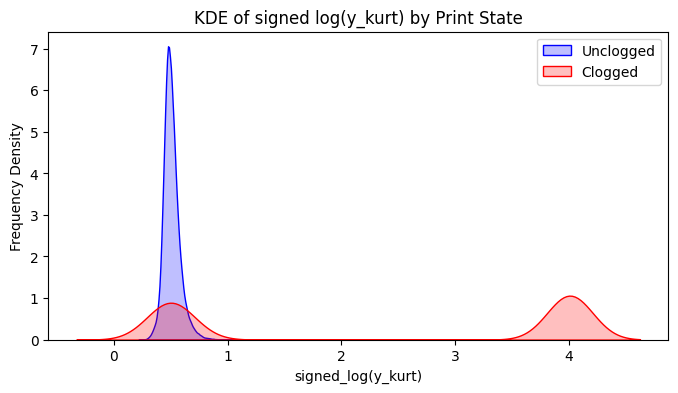

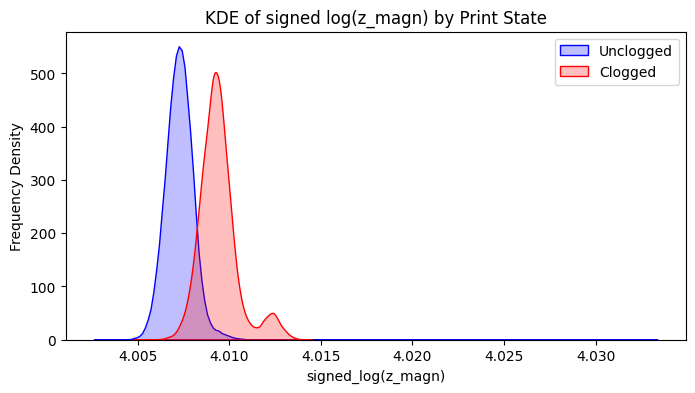

In [29]:
# KERNEL DENSITY PLOT
for feat in features_to_viz:
    plt.figure(figsize=(8, 4))
    
    sns.kdeplot(signed_log(unclogged_df[feat]), label="Unclogged", color='blue', fill=True)
    sns.kdeplot(signed_log(clogged_df[feat]), label="Clogged", color='red', fill=True)
    
    plt.title(f"KDE of signed log({feat}) by Print State")
    plt.xlabel(f"signed_log({feat})")
    plt.ylabel("Frequency Density")
    plt.legend()
    plt.show()

Want to check **correlation of features** to make sure we don't have super redudant / correlated features, which could throw the model off!

I'm primarily concerned with whether the combined-axis features are extremely redudant (ie potentially dominated by) any of the individual-axis features.

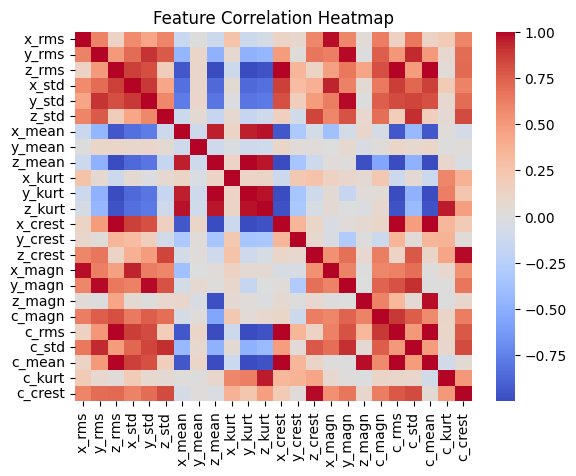

In [30]:
corr = train_df.drop(columns=['timestamp','print_id','print_state','state_flag']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title(f"Feature Correlation Heatmap")
plt.show()

There are some interesting and unexpected correlations, such as c_mean and z_rms, but since one's calculation does not directly involve the other (like if it were c_mean and z_mean), I'll keep them in the feature set.

Now let's look at the correlation of features with the print state (state_flag):

/var/folders/gr/05c8y4xn1g5fnnl7p5x3rbzm0000gn/T/ipykernel_25585/2930150451.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')


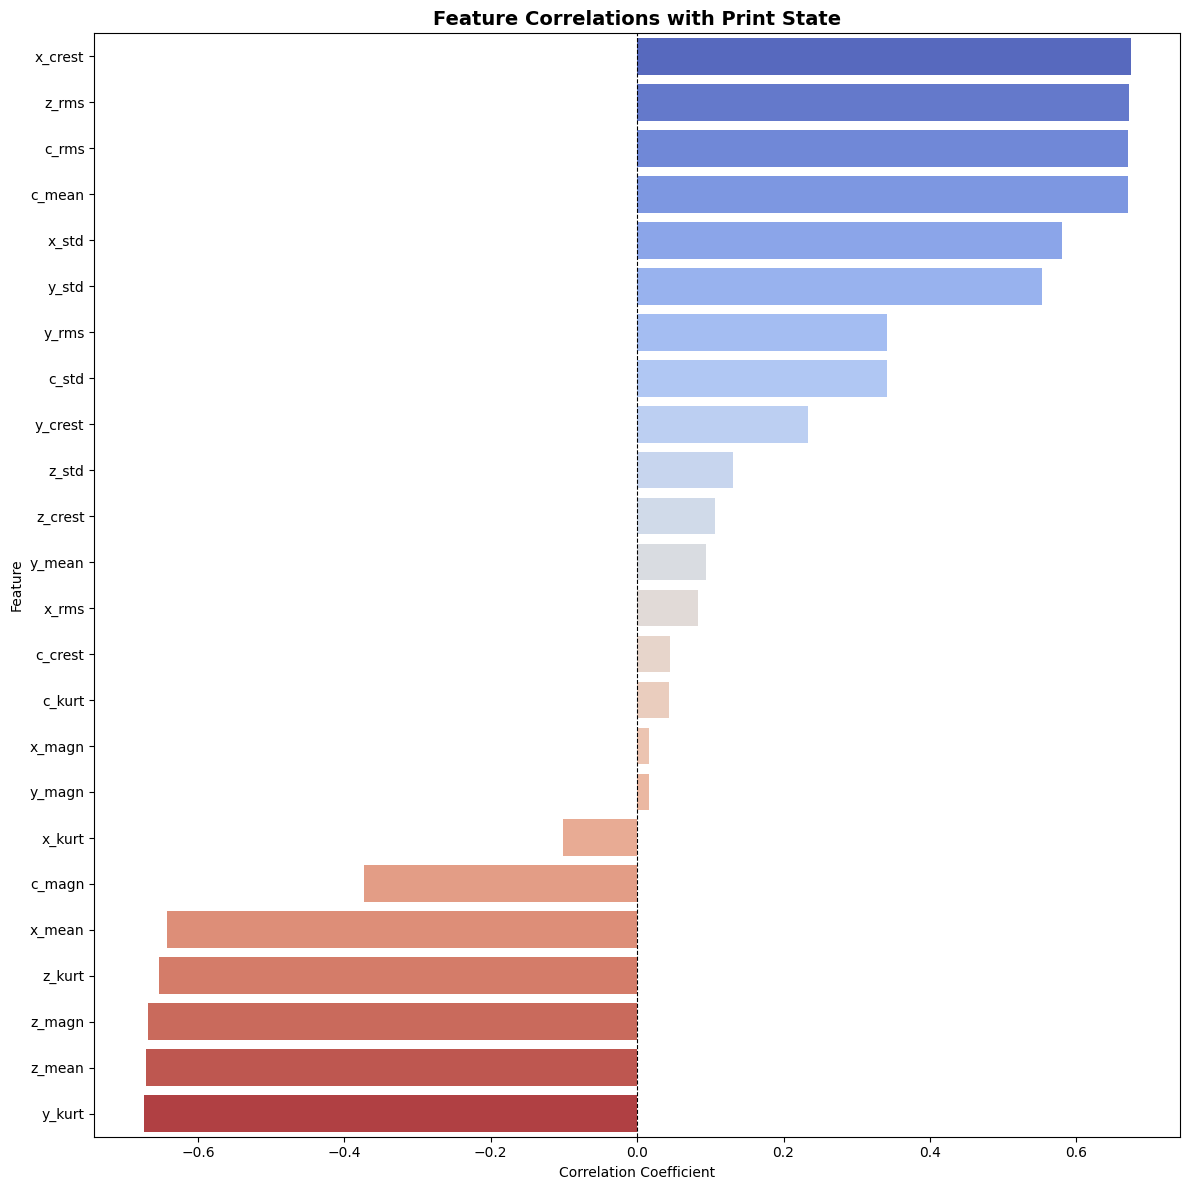

In [36]:
numeric_features = train_df.select_dtypes(include=np.number).columns.tolist()
numeric_features.remove('state_flag')  # exclude the target itself

correlations = train_df[numeric_features + ['state_flag']].corr()['state_flag'].sort_values(ascending=False)
correlations = correlations.drop('state_flag')

plt.figure(figsize=(12, max(12, len(correlations) * 0.15)))
sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')
plt.title('Feature Correlations with Print State', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

# Let's Start Modeling!

The dataset is likely full of non-linearly-separable relationships. Existing research has used support vector machines for similar types of data, but because I would have to use a kernel, it might be slow. Therefore I'm starting with a **Random Forest classifier**, which is an ensemble method that is well equipped to handle non-linearities.

Note that because RF is a decision-tree based method, it's not sensitive to scale.

In [38]:
feature_cols = train_df.drop(columns=['timestamp','print_id','print_state','state_flag']).columns

X_train = train_df[feature_cols]
y_train = train_df['state_flag']

X_val = val_df[feature_cols]
y_val = val_df['state_flag']

In [39]:
rf = RandomForestClassifier(
    n_estimators=200,       # number of trees
    max_depth=None,         # or limit to reduce overfitting
    random_state=42,
    n_jobs=-1               # use all CPU cores
)

rf.fit(X_train, y_train)
print("Done fitting")

Done fitting


In [42]:
# Validation
y_val_pred = rf.predict(X_val)
print("Validation Set Metrics:")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred, pos_label=1))
print("Recall:", recall_score(y_val, y_val_pred, pos_label=1))
print("F1 Score:", f1_score(y_val, y_val_pred, pos_label=1))

Validation Set Metrics:

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.81      0.89     22768
           1       0.73      0.99      0.84     11973

    accuracy                           0.87     34741
   macro avg       0.87      0.90      0.87     34741
weighted avg       0.91      0.87      0.88     34741


Confusion Matrix:
[[18478  4290]
 [   79 11894]]
Accuracy: 0.874240810569644
Precision: 0.7349233811171527
Recall: 0.9934018207633842
F1 Score: 0.844834321838264


In [48]:
print(f"Validation set shape: {val_df.shape}")
print(f"Validation set distribution:\n{val_df['state_flag'].value_counts().sort_index()}")

Validation set shape: (34741, 28)
Validation set distribution:
state_flag
0    22768
1    11973
Name: count, dtype: int64


# Now Let's Train the Full Model

In [44]:
# Build the full training dataset by combining train and validation
full_train_df = pd.concat((train_df, val_df))
#full_feature_cols = full_train_df.drop(columns=['timestamp','print_id','print_state','state_flag']).columns

X_train_full = full_train_df[feature_cols]
y_train_full = full_train_df['state_flag']

X_test = test_df[feature_cols]
y_test= test_df['state_flag']

In [45]:
# train full model
rf.fit(X_train_full, y_train_full)
print("Done fitting full model")

Done fitting full model


In [46]:
# Validation
y_test_pred = rf.predict(X_test)
print("Test Set Metrics:")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, pos_label=1))
print("Recall:", recall_score(y_test, y_test_pred, pos_label=1))
print("F1 Score:", f1_score(y_test, y_test_pred, pos_label=1))

Test Set Metrics:

Classification Report:
              precision    recall  f1-score   support

           0       0.63      1.00      0.78      7440
           1       1.00      0.92      0.96     54346

    accuracy                           0.93     61786
   macro avg       0.82      0.96      0.87     61786
weighted avg       0.96      0.93      0.94     61786


Confusion Matrix:
[[ 7440     0]
 [ 4286 50060]]
Accuracy: 0.9306315346518629
Precision: 1.0
Recall: 0.9211349501343246
F1 Score: 0.9589487194222555


In [47]:
print(f"Test set shape: {test_df.shape}")
print(f"Test set distribution:\n{test_df['state_flag'].value_counts().sort_index()}")

Test set shape: (61786, 28)
Test set distribution:
state_flag
0     7440
1    54346
Name: count, dtype: int64


The confusion matrix shows very high recall (1.0) on clogged print detection, which is great! For detecting errors such as clogs, we'd prefer having a few more false positives over potentially missing a clog that can ruin a print and cause a loss of print time and resources. 

# Pushing Model Further on New/Unseen Geometries
Now let's retrain and retest the model on a different split of prints (still no data leakage involved) that has a higher representation of new/unseen geometries in the test set (ie geometries not included in training).

In [49]:
# LOAD TRAIN, VALIDATION, AND TEST DATASETS
seen_train_file = "datasets/seen_train.csv"
unseen_test_file = "datasets/unseen_test.csv"

seen_train_df = pd.read_csv(seen_train_file)
unseen_test_df = pd.read_csv(unseen_test_file)

seen_train_df.head()

,timestamp,print_id,print_state,state_flag,x_rms,y_rms,z_rms,x_std,y_std,z_std,...,z_crest,x_magn,y_magn,z_magn,c_magn,c_rms,c_std,c_mean,c_kurt,c_crest
0,1970-01-01 00:00:00.000019155,cube_12,c,0,487.510865,905.717837,10215.209262,487.443856,900.986628,698.916674,...,1.177431,348.407280,657.960837,10191.271547,10242.560020,10266.863782,1240.106017,10191.694117,3.110367,1.189515
1,1970-01-01 00:00:00.000019155,cube_12,c,0,477.838913,898.413329,10205.867126,477.787683,891.820874,673.699099,...,1.178508,343.097116,659.556638,10183.607087,10233.800777,10256.471144,1215.522939,10184.188937,3.252890,1.190721
2,1970-01-01 00:00:00.000019155,cube_12,c,0,442.894356,835.603666,10216.830054,430.077864,835.491452,605.426888,...,1.177244,328.133294,628.064742,10198.876146,10241.993621,10260.507066,1117.834805,10199.433837,3.318028,1.190252
3,1970-01-01 00:00:00.000019156,cube_12,c,0,413.456538,803.234300,10174.561581,384.546042,800.841363,570.057400,...,1.182134,312.959072,626.880412,10158.579523,10198.097593,10214.589321,1055.551034,10159.903888,3.347303,1.187649
4,1970-01-01 00:00:00.000019156,cube_12,c,0,417.216211,725.643483,10194.984910,365.503441,718.141549,530.381535,...,1.164737,311.330619,570.402699,10181.179340,10215.109109,10229.288595,964.688873,10183.698765,3.144375,1.164075


In [52]:
X_seen_train = seen_train_df[feature_cols]
y_seen_train = seen_train_df['state_flag']

X_unseen_test = unseen_test_df[feature_cols]
y_unseen_test= unseen_test_df['state_flag']

In [53]:
rf.fit(X_seen_train, y_seen_train)
print("Done fitting seen train data")

y_unseen_test_pred = rf.predict(X_unseen_test)
print("Test Set Metrics (More Unseen Geometries):")

print("\nClassification Report:")
print(classification_report(y_unseen_test, y_unseen_test_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_unseen_test, y_unseen_test_pred))


Done fitting seen train data
Test Set Metrics (More Unseen Geometries):

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.88      0.92     40013
           1       0.88      0.95      0.92     37820

    accuracy                           0.92     77833
   macro avg       0.92      0.92      0.92     77833
weighted avg       0.92      0.92      0.92     77833


Confusion Matrix:
[[35216  4797]
 [ 1725 36095]]


Recall on clogged prints is slightly lower here (0.88), but still pretty good given that the dataset overall was on the small side and the clogged geometries were not in the training set!